# Pypower (runpf, newtonpf) 심층 분석 튜토리얼
이 노트북의 목적은 PGLib-OPF 케이스 데이터를 pypower로 로드하고, runpf와 newtonpf 함수의 내부 동작을 단계별로 분석하는 것입니다.

조류 계산의 핵심 요소인 Admittance Matrix (Y-bus), 버스 타입 (PV, PQ), 그리고 자코비안 행렬 (Jacobian Matrix)의 형태와 의미를 파악하고 시각화합니다.

In [3]:
import os
import numpy as np
import scipy.io
from pypower.api import loadcase, makeYbus, runpf
import matplotlib.pyplot as plt
import time

%matplotlib inline

In [4]:
DATA_DIR = "/workspace/datasets/pf_dataset"

# 분석할 케이스 파일을 선택합니다. (예: 118 버스 시스템)
# 파일 이름은 'pglib_opf_case118_ieee.mat'와 같은 형식이어야 합니다.
CASE_NAME = 'pglib_opf_case118_ieee.mat'
case_path = os.path.join(DATA_DIR, CASE_NAME)

ppc = {}
try:
    print(f"Loading case: {case_path}")

    ppc = loadcase(case_path)
            
    print(f"Case '{CASE_NAME}' loaded successfully.")

except FileNotFoundError:
    print(f"Error: File not found at {case_path}")
    print(f"Available files (sample): {os.listdir(DATA_DIR)[:5]}")
except KeyError:
    print("Error: 'mpc' key not found. .mat 파일이 'mpc' 키로 올바르게 저장되었는지 확인하세요.")

Loading case: /workspace/datasets/pf_dataset/pglib_opf_case118_ieee.mat
Case 'pglib_opf_case118_ieee.mat' loaded successfully.


## 1. 입력 데이터 분석
ppc (PYPOWER Case) 딕셔너리는 조류 계산에 필요한 모든 정보를 담고 있습니다.

- baseMVA: 시스템의 기준 용량 (MVA)

- bus: 각 버스의 정보 (타입, 부하 P/Q, 전압 초기값 등)

- gen: 각 발전기의 정보 (연결된 버스, 출력 P/Q, 한계값 등)

- branch: 각 선로(branch)의 정보 (연결된 버스, R, X, B 등)

In [5]:
print(f"--- Case Statistics: {CASE_NAME} ---")
    
base_mva = ppc.get('baseMVA', 'N/A')
bus_shape = ppc.get('bus', np.array([])).shape
gen_shape = ppc.get('gen', np.array([])).shape
branch_shape = ppc.get('branch', np.array([])).shape

print(f"  Base MVA: {base_mva}")
print(f"\n  Matrix Shapes:")
print(f"    Bus Data:    {bus_shape}")
print(f"    Gen Data:    {gen_shape}")
print(f"    Branch Data: {branch_shape}")

print(f"\n  Element Counts:")
print(f"    Number of Buses:      {bus_shape[0]}")
print(f"    Number of Generators: {gen_shape[0]}")
print(f"    Number of Branches:   {branch_shape[0]}")

--- Case Statistics: pglib_opf_case118_ieee.mat ---
  Base MVA: [100]

  Matrix Shapes:
    Bus Data:    (118, 13)
    Gen Data:    (54, 21)
    Branch Data: (186, 13)

  Element Counts:
    Number of Buses:      118
    Number of Generators: 54
    Number of Branches:   186


## 2. runpf 핵심 전처리
runpf는 조류 계산 전 두 가지 중요한 전처리를 수행합니다. 이 과정은 makeYbus와 newtonpf가 올바르게 동작하기 위해 필수적입니다.

Branch 행렬 패딩(Padding): PGLib 원본 데이터에는 조류 계산 결과가 저장될 PF, QF, PT, QT 열이 없습니다. pypower는 이 열들이 존재한다고 가정하므로, QT 인덱스까지 0으로 채워진 열을 덧붙여 행렬 크기를 표준에 맞춥니다.

- ext2int (External to Internal Indexing):

- External: PGLib의 버스 번호는 [1, 5, 12, 100, ...]처럼 불연속적일 수 있습니다.

- Internal: Ybus나 Jacobian 같은 행렬은 (N x N) 크기를 가지며, 인덱스가 [0, 1, 2, ..., N-1]처럼 0부터 시작하는 연속적인 정수라고 가정합니다.

ext2int는 버스 번호를 0부터 시작하는 내부 인덱스로 재매핑(re-mapping)하고, branch와 gen의 버스 번호도 모두 이 내부 인덱스로 교체합니다.

In [6]:
from pypower.ext2int import ext2int  # <-- 내부 인덱싱 변환 함수
from pypower.bustypes import bustypes
from pypower.idx_bus import PD, QD, VM, VA, GS, BUS_TYPE, PV, PQ, REF
from pypower.idx_brch import PF, PT, QF, QT
from pypower.idx_gen import PG, QG, VG, QMAX, QMIN, GEN_BUS, GEN_STATUS
from numpy import r_, c_, ix_, zeros, pi, ones, exp, argmax, union1d

from pypower.ext2int import ext2int

ppc["branch"] = c_[ppc["branch"],
                        zeros((ppc["branch"].shape[0],
                                QT - ppc["branch"].shape[1] + 1))]

## convert to internal indexing
ppc = ext2int(ppc)
baseMVA, bus, gen, branch = \
    ppc["baseMVA"], ppc["bus"], ppc["gen"], ppc["branch"]

print("Calculating Y-bus (Admittance Matrix)...")



Calculating Y-bus (Admittance Matrix)...
Y-bus calculation complete.
  Y-bus shape: (118, 118)
  Data type: complex128 (Complex)
  Non-zero elements: 476


## 3. 조류 계산 핵심 요소 (Y-bus, PV, PQ)
### 3.1. Admittance Matrix (Y-bus)

Ybus (Admittance Matrix)는 시스템의 토폴로지(연결 구조)를 나타내는 (N x N) 크기의 복소수 행렬입니다.

- 대각 요소 (Y_ii): i번 버스의 Self-Admittance. i번 버스에 연결된 모든 선로와 션트(shunt)의 어드미턴스 합.

- 비대각 요소 (Y_ij): i번 버스와 j번 버스 사이의 Mutual-Admittance. i와 j를 연결하는 선로 어드미턴스 값의 음수.

- 희소성 (Sparsity): 대부분의 버스는 몇 개의 다른 버스와만 연결되므로 Ybus는 0이 아닌 요소가 매우 적은 희소 행렬(Sparse Matrix)입니다.

In [12]:
Ybus, Yf, Yt = makeYbus(ppc['baseMVA'], ppc['bus'], ppc['branch'])

print("Y-bus calculation complete.")
print(f"  Y-bus shape: {Ybus.shape}")
print(f"  Data type: {Ybus.dtype} (Complex)")
print(f"  Non-zero elements: {Ybus.nnz}")

Y-bus calculation complete.
  Y-bus shape: (118, 118)
  Data type: complex128 (Complex)
  Non-zero elements: 476


### 3.2. Y-bus 시각화
plt.spy()는 행렬에서 0이 아닌 요소의 위치를 시각화하여 희소 행렬의 구조를 파악하는 데 매우 유용합니다.

Visualizing Y-bus (Sparsity Pattern)...


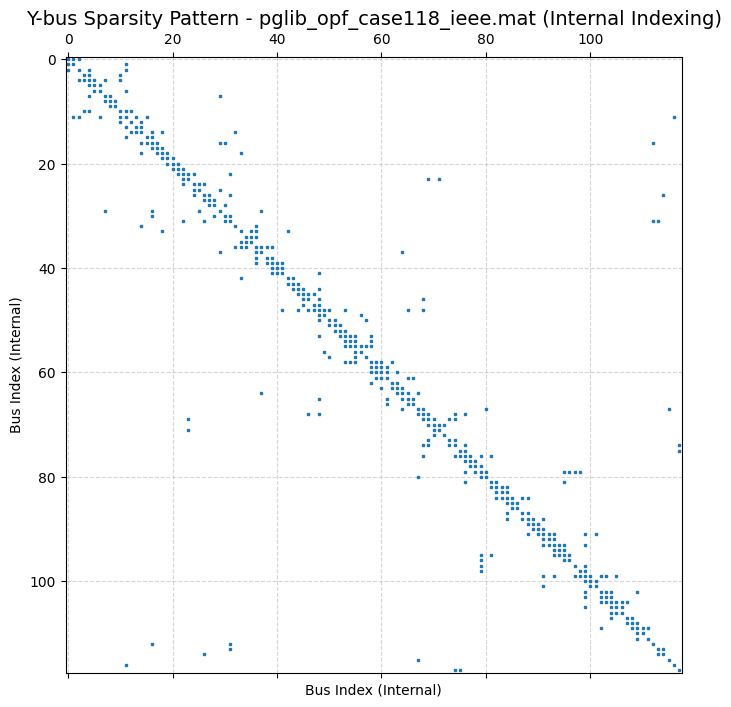

In [14]:
print("Visualizing Y-bus (Sparsity Pattern)...")

plt.figure(figsize=(10, 8))
# plt.spy()는 0이 아닌 요소(non-zero)의 위치를 점으로 표시합니다.
plt.spy(Ybus, markersize=1.5)
plt.title(f'Y-bus Sparsity Pattern - {CASE_NAME} (Internal Indexing)', fontsize=14)
plt.xlabel('Bus Index (Internal)')
plt.ylabel('Bus Index (Internal)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 3.3. 버스 타입 분류 (ref, pv, pq)
뉴턴-랩슨 알고리즘은 버스 타입에 따라 다른 방정식을 풉니다. bustypes 함수는 내부 인덱싱된 bus, gen 데이터를 기반으로 버스 인덱스를 세 그룹으로 분류합니다.
- ref (Reference Bus, Slack Bus): 기준이 되는 버스. 전압($V$)과 위상($\delta$)이 고정됩니다. (미지수: $P, Q$)
- pv (Voltage-Controlled Bus): 발전기 버스. 전력($P$)과 전압($V$)이 고정됩니다. (미지수: $Q, \delta$)
- pq (Load Bus): 부하 버스. 전력($P$)과 무효전력($Q$)이 고정(소비)됩니다. (미지수: $V, \delta$)

In [15]:
ref, pv, pq = bustypes(bus, gen)

## generator info
on = np.flatnonzero(gen[:, GEN_STATUS] > 0)      ## which generators are on?
gbus = gen[on, GEN_BUS].astype(int)    ## what buses are they at?

### 3.4. 초기 전압 (V0)
뉴턴-랩슨은 반복(iterative) 방식이므로 초기 추정값이 필요합니다. pypower는 "Flat Start" (모든 $V=1.0$, $\delta=0$) 대신, bus 행렬에 저장된 VM (Voltage Magnitude)과 VA (Voltage Angle) 값을 초기값 V0로 사용합니다.

In [8]:
## initial state
# V0    = ones(bus.shape[0])            ## flat start
V0  = bus[:, VM] * exp(1j * pi/180 * bus[:, VA])
vcb = ones(V0.shape)    # create mask of voltage-controlled buses
vcb[pq] = 0     # exclude PQ buses
k = np.flatnonzero(vcb[gbus])     # in-service gens at v-c buses
V0[gbus[k]] = gen[on[k], VG] / abs(V0[gbus[k]]) * V0[gbus[k]]

## 4. 뉴턴-랩슨 (newtonpf) 알고리즘 분석
뉴턴-랩슨 방법은 전력 불일치(Power Mismatch)가 0이 되는 전압($V$, $\delta$)을 찾는 반복 알고리즘입니다.
### 4.1. 전력 불일치 (Mismatch)
매 반복마다 현재 전압($V$)으로 계산한 전력과, 우리가 주입하기로 지정한 전력(Sbus)의 차이를 계산합니다.
1. S_calc = V * conj(I): 현재 전압($V$)과 어드미턴스($Y_{bus}$)를 이용해 계산한 복소 전력.
    - I = Ybus * V (옴의 법칙)
    - S_calc = V * conj(Ybus * V)

2. S_spec = Sbus: 우리가 시스템에 주입하기로 지정한 복소 전력 (발전 - 부하).

3. Mismatch (mis) = S_calc - S_spec: 이 값이 0에 가까워지는 것이 목표입니다.

my_newtonpf의 mis = V * conj(Ybus * V) - Sbus (Line 27)가 이 계산을 수행합니다.

### 4.2. 자코비안 행렬 (Jacobian Matrix)
자코비안($J$)은 "전력 불일치(Mismatch)가 미지수($V, \delta$)에 대해 얼마나 민감하게 변하는가?"를 나타내는 편미분 행렬입니다.

$\begin{bmatrix} \Delta P \\ \Delta Q \end{bmatrix} = \begin{bmatrix} J_{11} & J_{12} \\ J_{21} & J_{22} \end{bmatrix} \begin{bmatrix} \Delta \delta \\ \Delta V \end{bmatrix}$

- J11 = dP / dδ: 유효 전력($P$)을 위상($\delta$)으로 편미분 (PV, PQ 버스)
- J12 = dP / dV: 유효 전력($P$)을 전압($V$)으로 편미분 (PQ 버스)
- J21 = dQ / dδ: 무효 전력($Q$)을 위상($\delta$)으로 편미분 (PQ 버스)
- J22 = dQ / dV: 무효 전력($Q$)을 전압($V$)으로 편미분 (PQ 버스)

pypower는 dSbus_dV 함수로 dS_dVa (위상 편미분)와 dS_dVm (전압 크기 편미분)을 계산하며, 이들을 조합하여 J11~J22를 만듭니다.

In [ ]:
from math import inf
from numpy import array, angle, exp, linalg, conj, r_

from scipy.sparse import hstack, vstack
from scipy.sparse.linalg import spsolve

from pypower.dSbus_dV import dSbus_dV

def my_newtonpf(Ybus, Sbus, V0, pv, pq):
    tolerance = 1e-8
    max_iter = 10
    
    converged = False
    i = 0
    V = V0
    Va = angle(V)
    Vm = abs(V)

    pvpq = r_[pv, pq]
    npv = len(pv)
    npq = len(pq)

    j1 = 0;         j2 = npv           ## j1:j2 - V angle of pv buses
    j3 = j2;        j4 = j2 + npq      ## j3:j4 - V angle of pq buses
    j5 = j4;        j6 = j4 + npq      ## j5:j6 - V mag of pq buses

    while (not converged and i < max_iter):

        mis = V * conj(Ybus * V) - Sbus
        F = r_[  mis[pv].real,
                mis[pq].real,
                mis[pq].imag  ]

        ## check tolerance
        normF = linalg.norm(F, inf)

        if normF < tolerance:
            converged = True
            print(f"Converged at {i}")
            continue

        i += 1

        dS_dVm, dS_dVa = dSbus_dV(Ybus, V)

        J11 = dS_dVa[array([pvpq]).T, pvpq].real
        J12 = dS_dVm[array([pvpq]).T, pq].real
        J21 = dS_dVa[array([pq]).T, pvpq].imag
        J22 = dS_dVm[array([pq]).T, pq].imag

        J = vstack([
                hstack([J11, J12]),
                hstack([J21, J22])
            ], format="csr")

        dx = -1 * spsolve(J, F)

        ## update voltage
        if npv:
            Va[pv] = Va[pv] + dx[j1:j2]
        if npq:
            Va[pq] = Va[pq] + dx[j3:j4]
            Vm[pq] = Vm[pq] + dx[j5:j6]
        V = Vm * exp(1j * Va)
        Vm = abs(V)            ## update Vm and Va again in case
        Va = angle(V) 
    
    return V, converged, i

### 4.3. 자코비안 시각화자코비안 행렬($J$)도 Ybus와 마찬가지로 희소 행렬입니다. 

Ybus의 구조(연결성)가 J의 구조를 결정하기 때문입니다.

plt.spy()로 J를 시각화하면 뉴턴-랩슨이 풀고 있는 선형 방정식의 구조를 볼 수 있습니다.

In [ ]:
# Sbus를 먼저 계산해야 my_newtonpf를 호출할 수 있습니다.
from pypower.makeSbus import makeSbus
Sbus = makeSbus(baseMVA, bus, gen)

# J_vis를 얻기 위해 함수를 호출합니다.
V_temp, converged_temp, i_temp, J_vis = my_newtonpf(Ybus, Sbus, V0, pv, pq)

if J_vis is not None:
    print(f"Visualizing Jacobian Sparsity Pattern (Iteration 1)...")
    print(f"  Jacobian Shape: {J_vis.shape}")
    print(f"  (N_pv + N_pq) + N_pq = ({len(pv)} + {len(pq)}) + {len(pq)} = {len(pv) + 2*len(pq)}")

    plt.figure(figsize=(10, 8))
    plt.spy(J_vis, markersize=1.0)
    plt.title(f'Jacobian Sparsity Pattern - {CASE_NAME}', fontsize=16)
    plt.xlabel('State Variables (Delta_pv, Delta_pq, V_pq)')
    plt.ylabel('Mismatch Equations (P_pv, P_pq, Q_pq)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
else:
    print("Jacobian (J_vis)가 캡처되지 않았습니다.")

In [11]:
from pypower.makeSbus import makeSbus
from pypower.newtonpf import newtonpf
from pypower.pfsoln import pfsoln

Sbus = makeSbus(baseMVA, bus, gen)

t0 = time.time()
V, success, _ = my_newtonpf(Ybus, Sbus, V0, pv, pq)
t1 = time.time()

## update data matrices with solution
bus, gen, branch = pfsoln(baseMVA, bus, gen, branch, Ybus, Yf, Yt, V, ref, pv, pq)



Converged at 4


## 5. 조류 계산 실행 및 결과 확인

이제 my_newtonpf 함수를 사용하여 조류 계산을 실행하고, pfsoln으로 결과를 ppc 객체에 다시 업데이트합니다.

In [23]:
from pypower.int2ext import int2ext
from pypower.printpf import printpf

ppc["bus"], ppc["gen"], ppc["branch"] = bus, gen, branch
results = int2ext(ppc)
results["success"] = success
results["et"] = t1 - t0

## zero out result fields of out-of-service gens & branches
if len(results["order"]["gen"]["status"]["off"]) > 0:
    results["gen"][ix_(results["order"]["gen"]["status"]["off"], [PG, QG])] = 0

if len(results["order"]["branch"]["status"]["off"]) > 0:
    results["branch"][ix_(results["order"]["branch"]["status"]["off"], [PF, QF, PT, QT])] = 0

printpf(results)


Converged in 0.02 seconds
|     System Summary                                                           |

How many?                How much?              P (MW)            Q (MVAr)
---------------------    -------------------  -------------  -----------------
Buses            118     Total Gen Capacity    6515.0       -5777.0 to 7954.0
Generators        54     On-line Capacity      6515.0       -5777.0 to 7954.0
Committed Gens    54     Generation (actual)   4486.1            1488.6
Loads             99     Load                  4242.0            1438.0
  Fixed           99       Fixed               4242.0            1438.0
  Dispatchable     0       Dispatchable           0.0 of 0.0        0.0
Shunts            14     Shunt (inj)             -0.0              85.0
Branches         186     Losses (I^2 * Z)       244.15           1459.73
Transformers      11     Branch Charging (inj)     -             1324.1
Inter-ties         0     Total Inter-tie Flow     0.0               0.0
Area

In [21]:
print(type(Ybus))
print(f"  Data type: {Ybus.dtype}")
print(type(Sbus))
print(f"  Data type: {Sbus.dtype}")
print(type(pv))
print(f"  Data type: {pv.dtype}")
print(type(pq))
print(f"  Data type: {pq.dtype}")
print(type(V0))
print(f"  Data type: {V0.dtype}")

<class 'scipy.sparse._csc.csc_matrix'>
  Data type: complex128
<class 'numpy.ndarray'>
  Data type: complex128
<class 'numpy.ndarray'>
  Data type: int64
<class 'numpy.ndarray'>
  Data type: int64
<class 'numpy.ndarray'>
  Data type: complex128
